# Chili Pepper Multi-Source 

## Importing Libraries

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from skimage import io, transform
from sklearn import preprocessing
import joblib
import cv2
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import PassiveAggressiveClassifier
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.transform import resize
from skimage.io import imread

# Data Importing

In [2]:
path = r"C:\Users\yesku\Downloads\Chili  Multi-Source"
model_folder = r"model"
categories = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
categories

['Bari chilli',
 'Bombai chilli',
 'Cherry chilli',
 'Dry chilli',
 'Unhealthy chilli']

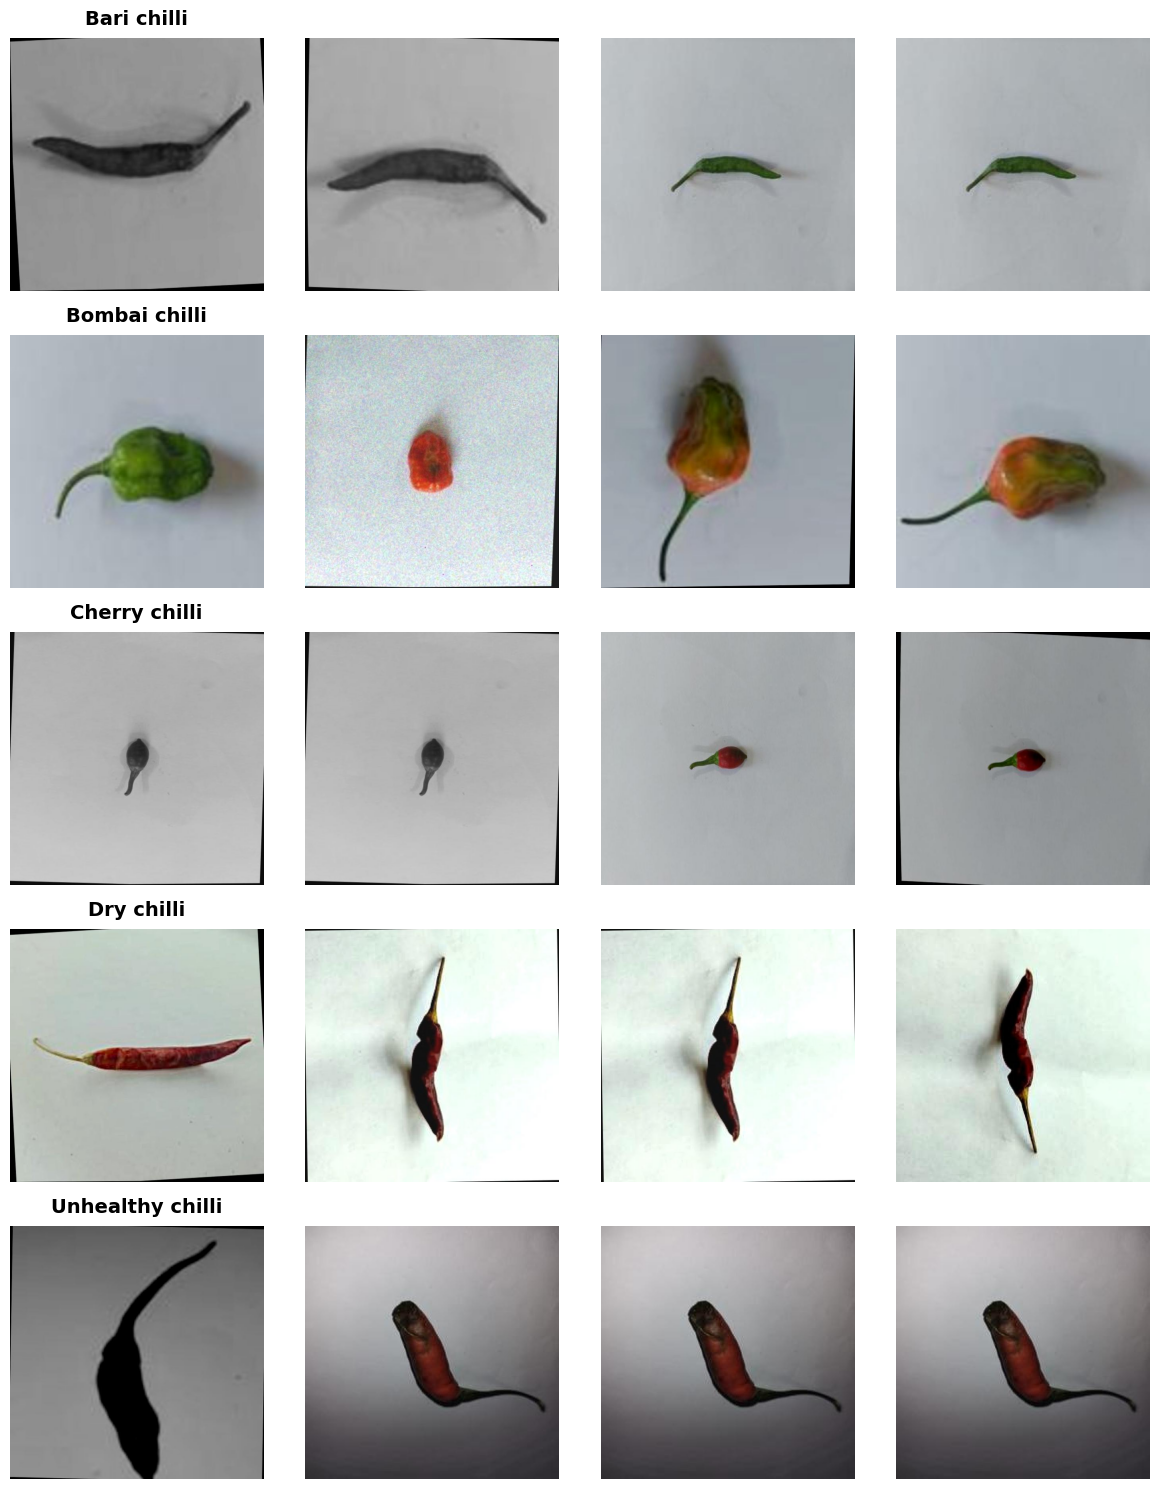

Final image saved at: results\classes_grid.png


In [3]:
num_classes = len(categories)
num_cols = 4  # 4 images per class

# Create results folder if it doesn't exist
results_folder = r"results"
os.makedirs(results_folder, exist_ok=True)

plt.figure(figsize=(num_cols * 3, num_classes * 3))

for i, category in enumerate(categories):
    folder_path = os.path.join(path, category)
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(("jpg", "jpeg", "png")) and 'Thumbs.db' not in f]
    
    selected_files = files[:4]  # pick 4 images per class
    
    for j, file in enumerate(selected_files):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR → RGB
        
        ax = plt.subplot(num_classes, num_cols, i * num_cols + j + 1)
        ax.imshow(img)
        ax.axis('off')
        
        # Add class name as a title above the first image of each row
        if j == 0:
            ax.set_title(category, fontsize=14, weight='bold', pad=10, loc='center')

plt.tight_layout()

# Save the final image
output_path = os.path.join(results_folder, "classes_grid.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Final image saved at: {output_path}")

#  Preprocessing

In [4]:
model_folder =  "model"
X_file = os.path.join(model_folder, "X.txt.npy")
Y_file = os.path.join(model_folder, "Y.txt.npy")
if os.path.exists(X_file) and os.path.exists(Y_file):
    X = np.load(X_file)
    Y = np.load(Y_file)
    print("X and Y arrays loaded successfully.")
else:
    X = [] # input array
    Y = [] # output array
    for root, dirs, directory in os.walk(path):
        for j in range(len(directory)):
            name = os.path.basename(root)
            print(f'Loading category: {dirs}')
            print(name+" "+root+"/"+directory[j])
            if 'Thumbs.db' not in directory[j]:
                img_array = cv2.imread(root+"/"+directory[j])
                img_resized = resize(img_array, (64, 64, 3))
                # Append the input image array to X
                X.append(img_resized.flatten())
                # Append the index of the category in categories list to Y
                Y.append(categories.index(name))
    X = np.array(X)
    Y = np.array(Y)
    np.save(X_file, X)
    np.save(Y_file, Y)

X and Y arrays loaded successfully.


In [5]:
df = pd.DataFrame(X)
df['Labels'] = Y
df

,0,1,2,3,4,5,6,7,8,9,...,12279,12280,12281,12282,12283,12284,12285,12286,12287,Labels
0,0.046513,0.046513,0.046513,0.055163,0.055163,0.055163,0.066323,0.066323,0.066323,0.081509,...,0.001232,0.001232,0.001232,0.000924,0.000924,0.000924,0.000622,0.000622,0.000622,0
1,0.070320,0.070320,0.070320,0.524772,0.524772,0.524772,0.665325,0.665325,0.665325,0.666420,...,0.708329,0.708329,0.708329,0.715267,0.715267,0.715267,0.677184,0.677184,0.677184,0
2,0.780417,0.768652,0.752966,0.780476,0.768712,0.753025,0.780362,0.768598,0.752911,0.771318,...,0.685204,0.673439,0.657753,0.667035,0.655270,0.639584,0.651934,0.640169,0.624483,0
3,0.780417,0.768652,0.752966,0.780476,0.768712,0.753025,0.780362,0.768598,0.752911,0.771318,...,0.685204,0.673439,0.657753,0.667035,0.655270,0.639584,0.651934,0.640169,0.624483,0
4,0.780417,0.768652,0.752966,0.780476,0.768712,0.753025,0.780362,0.768598,0.752911,0.771318,...,0.685204,0.673439,0.657753,0.667035,0.655270,0.639584,0.651934,0.640169,0.624483,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,0.134482,0.122877,0.130560,0.134693,0.123108,0.130772,0.138678,0.127119,0.134756,0.149112,...,0.007020,0.006931,0.006995,0.006464,0.006376,0.006435,0.005787,0.005699,0.005758,4
1246,0.134482,0.122877,0.130560,0.134693,0.123108,0.130772,0.138678,0.127119,0.134756,0.149112,...,0.007020,0.006931,0.006995,0.006464,0.006376,0.006435,0.005787,0.005699,0.005758,4
1247,0.125042,0.125042,0.125042,0.406640,0.406640,0.406640,0.472553,0.472553,0.472553,0.485898,...,0.075726,0.075726,0.075726,0.075607,0.075607,0.075607,0.075523,0.075523,0.075523,4
1248,0.216500,0.204736,0.212579,0.230441,0.218676,0.226519,0.241730,0.229252,0.237809,0.261716,...,0.022502,0.021559,0.025194,0.020942,0.020487,0.022090,0.006797,0.006780,0.006836,4


In [6]:
Y

array([0, 0, 0, ..., 4, 4, 4])

In [7]:
df.Labels.unique()

array([0, 1, 2, 3, 4])

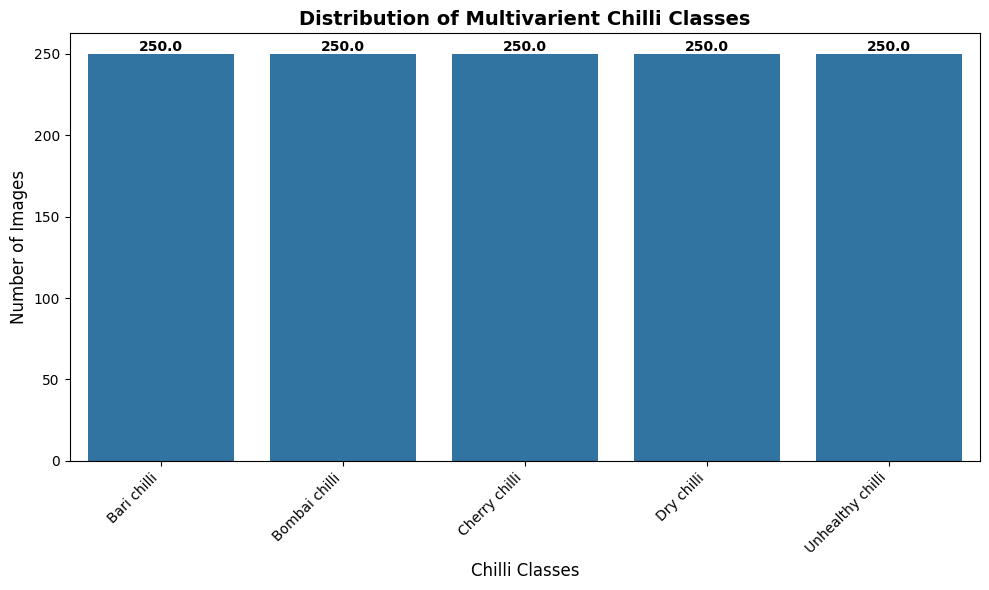

In [8]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=Y)

# Replace x-ticks with class names automatically
ax.set_xticklabels(categories, rotation=45, ha='right')

# Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel("Chilli Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Distribution of Multivarient Chilli Classes", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# Data Splitting

In [9]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=77)

In [10]:
x_train.shape

(875, 12288)

In [11]:
y_train.shape

(875,)

# Function to Calculate Metrics

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix

# ──────────────────────────────────────────────────────────────
# Global containers
# ──────────────────────────────────────────────────────────────
metrics_overall = []                    # Overall metrics
class_metrics_storage = {}              # Key = class name → list of dicts (one per model)
categories=['Bari chilli',
 'Bombai chilli',
 'Cherry chilli',
 'Dry chilli',
 'Unhealthy chilli']
def calculateMetrics(algorithm, predict, testY):
    """
    Call this for every model (RFC, DTC, NBC, etc.)
    """
    testY = testY.astype('int')
    predict = predict.astype('int')
    
    # ── Overall metrics ─────────────────────────────────────
    acc  = accuracy_score(testY, predict) * 100
    prec = precision_score(testY, predict, average='macro', zero_division=0) * 100
    rec  = recall_score(testY, predict, average='macro', zero_division=0) * 100
    f1   = f1_score(testY, predict, average='macro', zero_division=0) * 100
    
    metrics_overall.append({
        'Model': algorithm,
        'Accuracy':  round(acc, 2),
        'Precision': round(prec, 2),
        'Recall':    round(rec, 2),
        'F1-Score':  round(f1, 2)
    })
    
    print(f"\n=== {algorithm} Overall ===")
    print(f"Accuracy  : {acc:.2f}%")
    print(f"Precision : {prec:.2f}%")
    print(f"Recall    : {rec:.2f}%")
    print(f"F1-Score  : {f1:.2f}%\n")
    
    # ── Class-wise metrics ──────────────────────────────────
    report = classification_report(testY, predict, target_names=categories,
                                  output_dict=True, zero_division=0)
    print("\n=== Classification Report ===")
    print(classification_report(testY, predict, target_names=categories, zero_division=0))

    for cls in categories:
        # Initialize list for this class if first time
        if cls not in class_metrics_storage:
            class_metrics_storage[cls] = []
        
        class_metrics_storage[cls].append({
            'Model':     algorithm,
            'Precision': round(report[cls]['precision'] * 100, 2),
            'Recall':    round(report[cls]['recall'] * 100, 2),
            'F1-Score':  round(report[cls]['f1-score'] * 100, 2)
        })
    
    # ── Confusion matrix ────────────────────────────────────
    cm = confusion_matrix(testY, predict)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=categories, yticklabels=categories, cbar=False)
    plt.title(f"{algorithm} - Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Model Building and Training

## LGBM Classifier


=== LGBM Classifier Overall ===
Accuracy  : 98.93%
Precision : 98.94%
Recall    : 98.94%
F1-Score  : 98.94%


=== Classification Report ===
                  precision    recall  f1-score   support

     Bari chilli       1.00      1.00      1.00        91
   Bombai chilli       0.97      0.97      0.97        71
   Cherry chilli       1.00      1.00      1.00        62
      Dry chilli       0.98      0.98      0.98        81
Unhealthy chilli       1.00      1.00      1.00        70

        accuracy                           0.99       375
       macro avg       0.99      0.99      0.99       375
    weighted avg       0.99      0.99      0.99       375



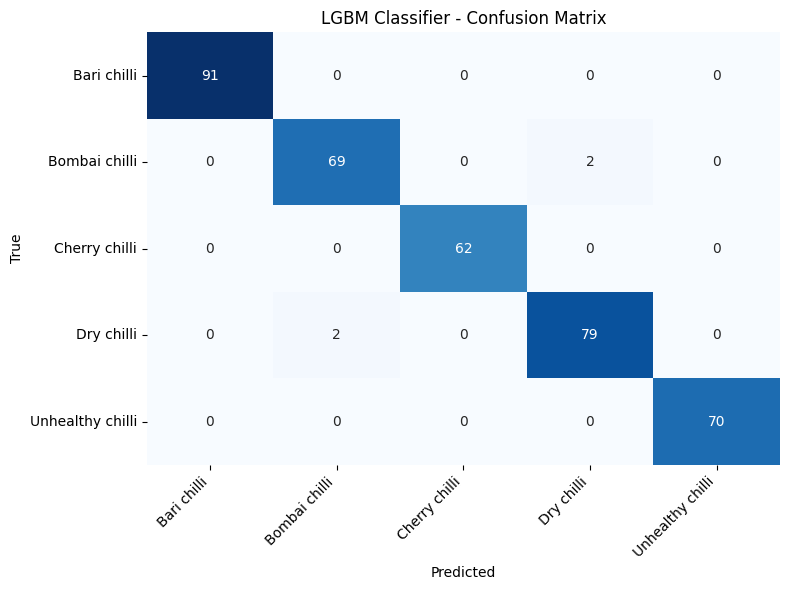

In [13]:
model_path = r"model\lgbm_classifier.pkl"

os.makedirs(os.path.dirname(model_path), exist_ok=True)

if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    lgbm_classifier = joblib.load(model_path)
    predict = lgbm_classifier.predict(x_test)
    calculateMetrics("LGBM Classifier", predict, y_test)

else:
    lgbm_classifier = LGBMClassifier()
    lgbm_classifier.fit(x_train, y_train)
    predict = lgbm_classifier.predict(x_test)
    joblib.dump(lgbm_classifier, model_path)
    calculateMetrics("LGBM Classifier", predict, y_test)


## LDA Classifier


=== LDA Classifier Overall ===
Accuracy  : 96.00%
Precision : 96.40%
Recall    : 96.16%
F1-Score  : 96.16%


=== Classification Report ===
                  precision    recall  f1-score   support

     Bari chilli       0.91      0.98      0.94        91
   Bombai chilli       0.97      0.99      0.98        71
   Cherry chilli       0.94      1.00      0.97        62
      Dry chilli       1.00      0.90      0.95        81
Unhealthy chilli       1.00      0.94      0.97        70

        accuracy                           0.96       375
       macro avg       0.96      0.96      0.96       375
    weighted avg       0.96      0.96      0.96       375



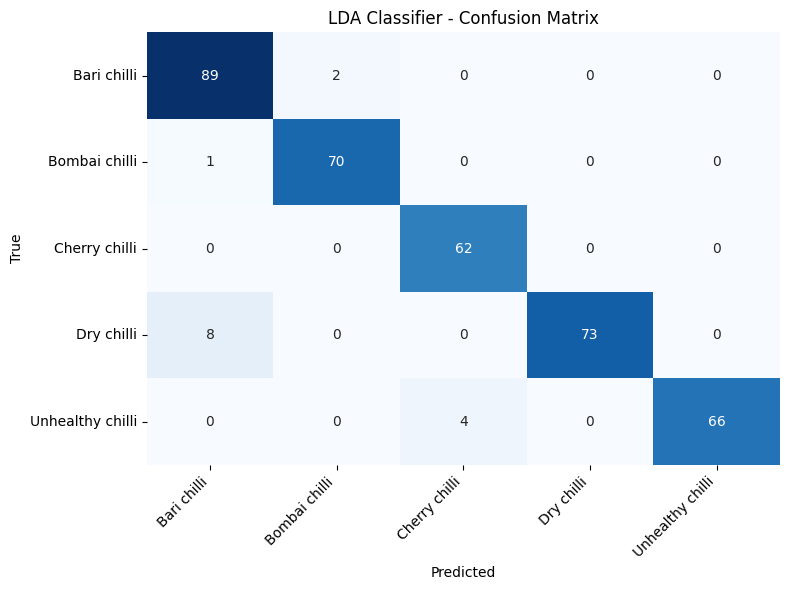

In [14]:

import joblib
import os

model_path = r"model\lda_classifier.pkl"

# Ensure folder exists before saving
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Load or train LDA Classifier model
if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    lda_clf = joblib.load(model_path)
    predict = lda_clf.predict(x_test)
    calculateMetrics("LDA Classifier", predict, y_test)
else:
    lda_clf = LinearDiscriminantAnalysis()
    lda_clf.fit(x_train, y_train)
    joblib.dump(lda_clf, model_path)

    predict = lda_clf.predict(x_test)
    calculateMetrics("LDA Classifier", predict, y_test)


## Adaboost Classifier


=== AdaBoost Classifier Overall ===
Accuracy  : 88.80%
Precision : 89.94%
Recall    : 88.73%
F1-Score  : 89.06%


=== Classification Report ===
                  precision    recall  f1-score   support

     Bari chilli       0.87      0.86      0.86        91
   Bombai chilli       0.93      0.80      0.86        71
   Cherry chilli       0.90      0.87      0.89        62
      Dry chilli       0.80      0.96      0.87        81
Unhealthy chilli       1.00      0.94      0.97        70

        accuracy                           0.89       375
       macro avg       0.90      0.89      0.89       375
    weighted avg       0.89      0.89      0.89       375



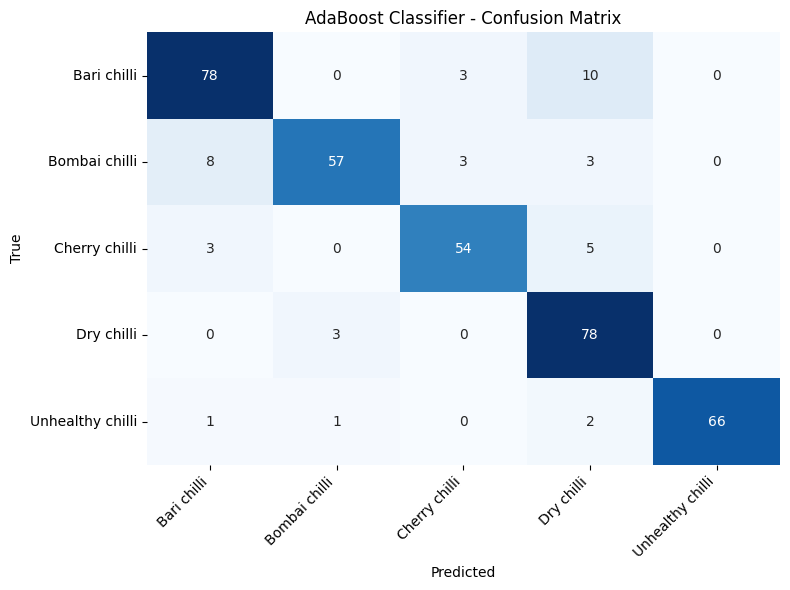

In [15]:
from sklearn.ensemble import AdaBoostClassifier
import joblib
import os

model_path = r"model\adaboost_classifier.pkl"

# Ensure folder exists before saving
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Load or train AdaBoost Classifier model
if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    ada_clf = joblib.load(model_path)
    predict = ada_clf.predict(x_test)
    calculateMetrics("AdaBoost Classifier", predict, y_test)
else:
    ada_clf = AdaBoostClassifier()
    ada_clf.fit(x_train, y_train)
    joblib.dump(ada_clf, model_path)

    predict = ada_clf.predict(x_test)
    calculateMetrics("AdaBoost Classifier", predict, y_test)


## SVM Classifier


=== SVM Classifier Overall ===
Accuracy  : 95.20%
Precision : 95.21%
Recall    : 95.67%
F1-Score  : 95.30%


=== Classification Report ===
                  precision    recall  f1-score   support

     Bari chilli       0.93      0.87      0.90        91
   Bombai chilli       0.97      0.92      0.94        71
   Cherry chilli       0.86      1.00      0.93        62
      Dry chilli       1.00      1.00      1.00        81
Unhealthy chilli       1.00      1.00      1.00        70

        accuracy                           0.95       375
       macro avg       0.95      0.96      0.95       375
    weighted avg       0.95      0.95      0.95       375



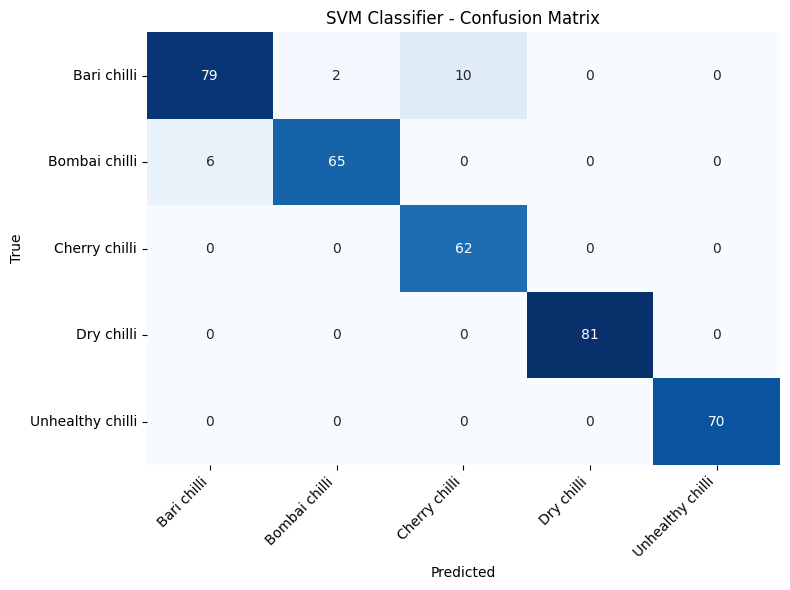

In [16]:

import joblib
import os

model_path = r"model\svm_classifier.pkl"

# Ensure folder exists before saving
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Load or train SVM Classifier model
if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    svm_clf = joblib.load(model_path)
    predict = svm_clf.predict(x_test)
    calculateMetrics("SVM Classifier", predict, y_test)
else:
    svm_clf = SVC()
    svm_clf.fit(x_train, y_train)
    joblib.dump(svm_clf, model_path)

    predict = svm_clf.predict(x_test)
    calculateMetrics("SVM Classifier", predict, y_test)


# Performance Comparision 

In [17]:
def create_per_class_dataframes():
    if not metrics_overall:
        print("No models evaluated yet!")
        return None

    overall_df = pd.DataFrame(metrics_overall)
    overall_df = overall_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
    
    print("\n" + "="*60)
    print("OVERALL MODEL COMPARISON")
    print("="*60)
    print(overall_df.round(4))
    print()

    class_dfs = {}
    for cls, records in class_metrics_storage.items():
        df = pd.DataFrame(records)
        df = df.set_index('Model')[['Precision', 'Recall', 'F1-Score']]
        
        var_name = cls.replace(" ", "_").replace("-", "_") + "_df"
        globals()[var_name] = df
        class_dfs[cls] = df   # key by original class name (more readable)

        print(f"{cls.upper()} CLASS PERFORMANCE".center(60))
        print("-" * 60)
        print(df.round(4))
        print()

    return overall_df, class_dfs
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 7)

def plot_overall_with_values():
    ax = overall_df.plot(kind='bar', width=0.8, edgecolor='black', alpha=0.9)
    plt.title('Overall Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Score (%)')
    plt.xlabel('Model')
    plt.ylim(0, 105)
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)

    # Add values on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()


def plot_per_class_metric_universal(metric_name):
    # Reconstruct correct class names from the original storage (universal!)
    class_names = list(class_metrics_storage.keys())  # e.g., ['Cirriform Clouds', 'Clear Sky', ...]
    
    # Build DataFrame: rows = models, columns = clean class names
    data = pd.DataFrame()
    for cls in class_names:
        records = class_metrics_storage[cls]
        df = pd.DataFrame(records).set_index('Model')
        data[cls] = df[metric_name]

    # Ensure same model order as overall_df
    data = data.loc[overall_df.index]

    # Plot
    plt.figure()
    ax = data.plot(kind='bar', width=0.82, edgecolor='black', alpha=0.9)
    
    plt.title(f'{metric_name} per Cloud Class', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel(f'{metric_name} (%)')
    plt.xlabel('Model')
    plt.ylim(0, 105)
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Cloud Class', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)

    # Add value labels on top of every bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=9.5, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [18]:
 overall_df, class_dfs = create_per_class_dataframes()


OVERALL MODEL COMPARISON
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
LGBM Classifier         98.93      98.94   98.94     98.94
LDA Classifier          96.00      96.40   96.16     96.16
AdaBoost Classifier     88.80      89.94   88.73     89.06
SVM Classifier          95.20      95.21   95.67     95.30

               BARI CHILLI CLASS PERFORMANCE                
------------------------------------------------------------
                     Precision  Recall  F1-Score
Model                                           
LGBM Classifier         100.00  100.00    100.00
LDA Classifier           90.82   97.80     94.18
AdaBoost Classifier      86.67   85.71     86.19
SVM Classifier           92.94   86.81     89.77

              BOMBAI CHILLI CLASS PERFORMANCE               
------------------------------------------------------------
                     Precision  Recall  F1-Score
Model                          

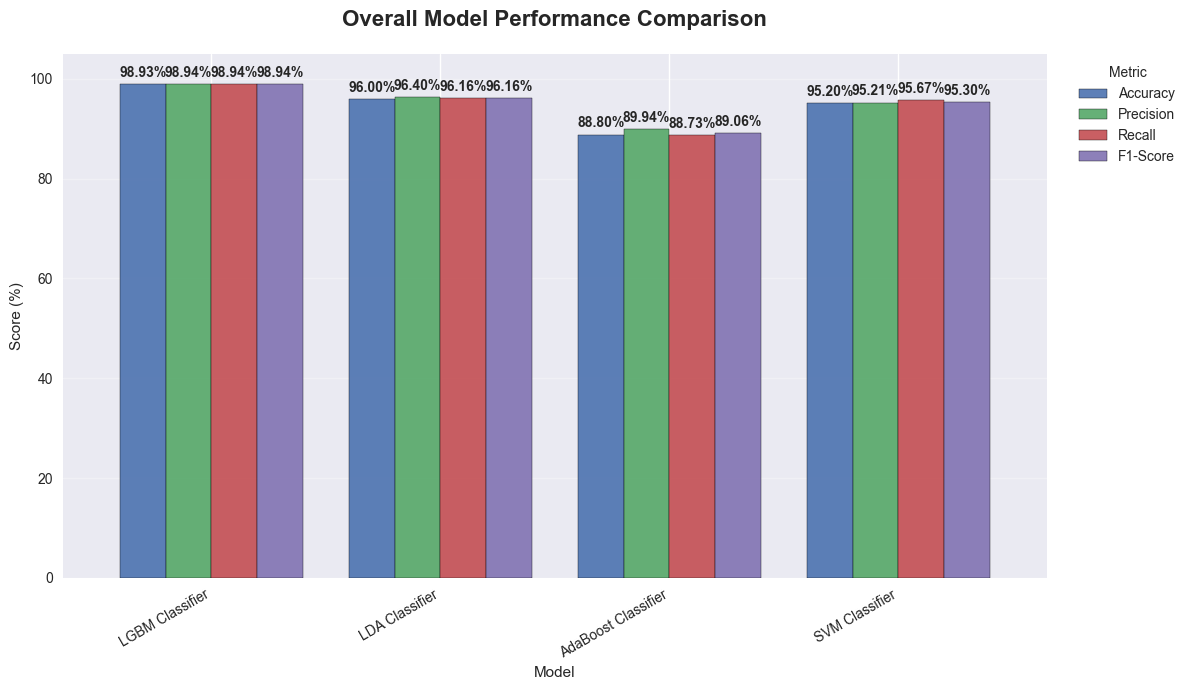

In [19]:
plot_overall_with_values()

<Figure size 1200x700 with 0 Axes>

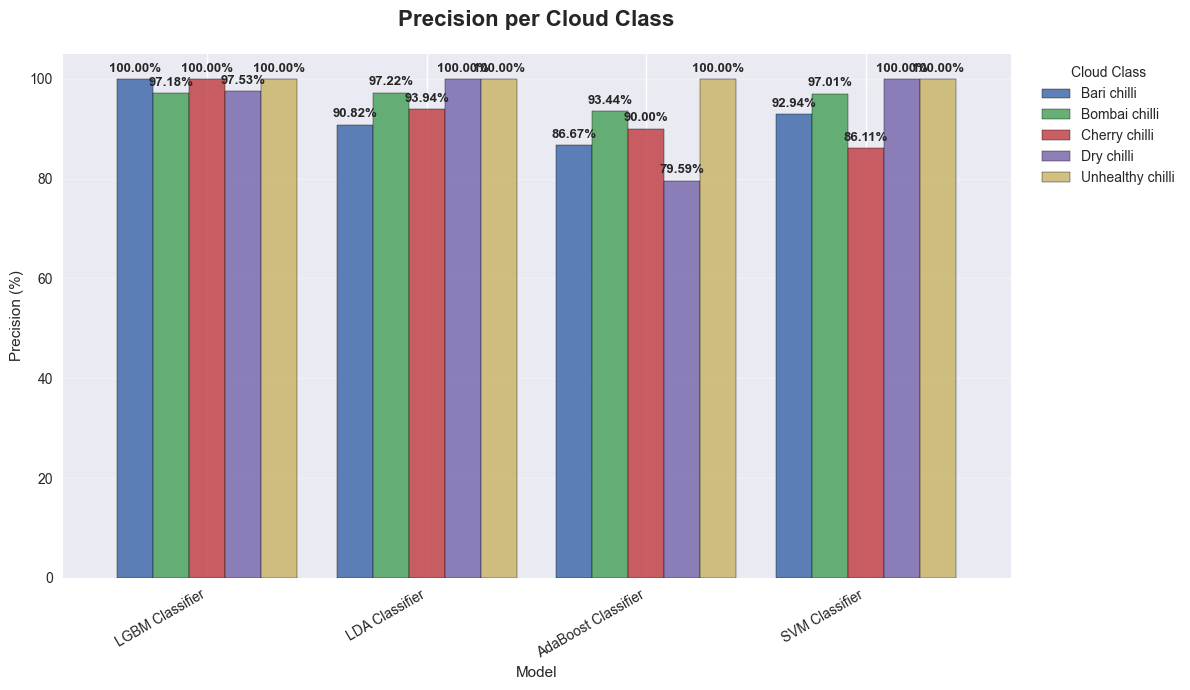

In [20]:
plot_per_class_metric_universal('Precision')

<Figure size 1200x700 with 0 Axes>

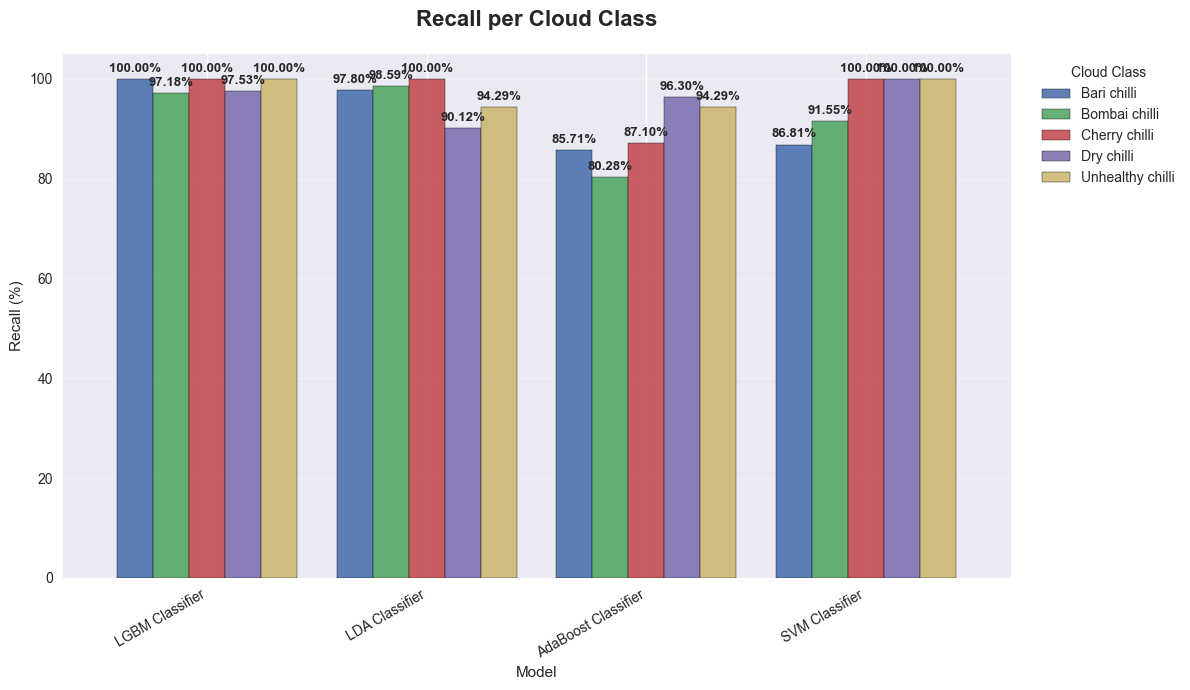

In [21]:
plot_per_class_metric_universal('Recall')

<Figure size 1200x700 with 0 Axes>

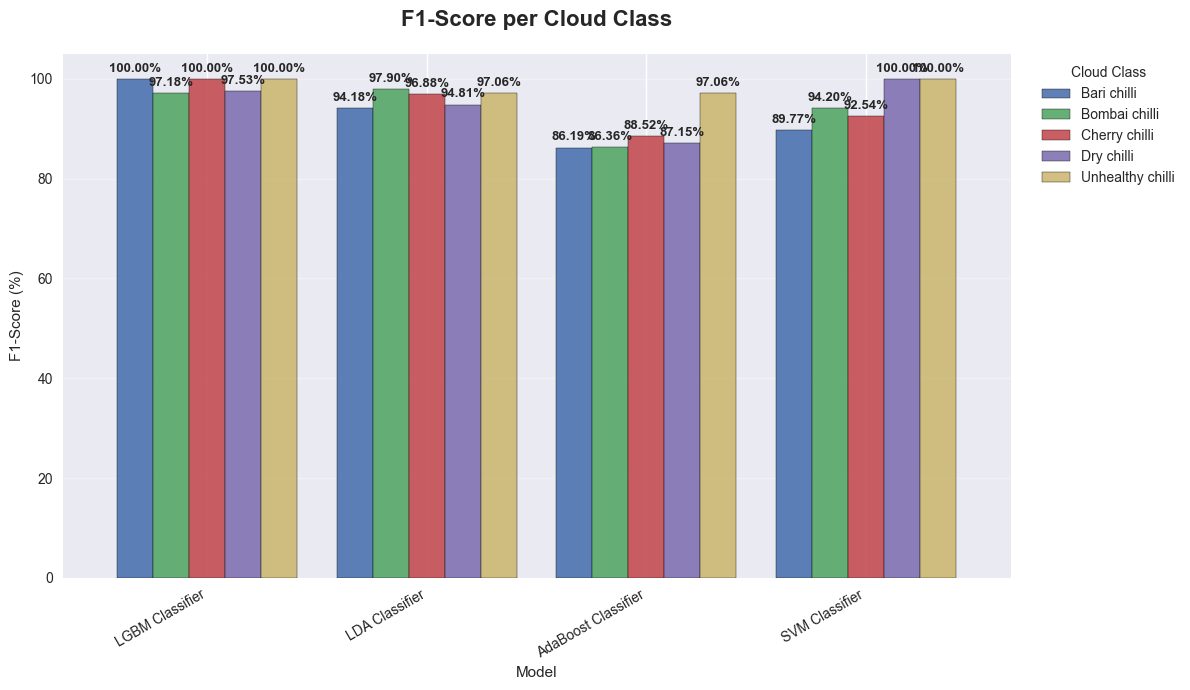

In [22]:
plot_per_class_metric_universal('F1-Score')

# Prediction on Test Image 

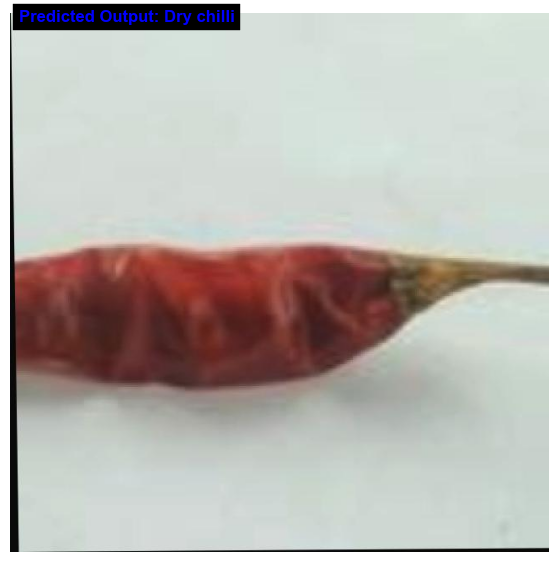

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array, load_img
LGBM_Classifier = joblib.load(r"model\lgbm_classifier.pkl")
categories=['Bari chilli',
 'Bombai chilli',
 'Cherry chilli',
 'Dry chilli',
 'Unhealthy chilli']
def predict_image(image_path):
    img = load_img(image_path, target_size=(64, 64))
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = img_array.flatten()
    img_array = np.expand_dims(img_array, axis=0)

    predicted_class = LGBM_Classifier.predict(img_array)[0]
    return predicted_class

image_path = r"C:\Users\yesku\Downloads\Chilli Dataset\Chilli Dataset\Chili  Multi-Source\Dry chilli\Dry_Chili5_jpg.rf.08a1658b874059f02a12dd5d17d21708_d308.jpg"

output_number = predict_image(image_path)
output_name = categories[output_number]

img = load_img(image_path)
plt.imshow(img)
plt.text(10, 10, f'Predicted Output: {output_name}', color='blue', fontsize=12, weight='bold', backgroundcolor='black')
plt.axis('off')
plt.show()
